In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

In [19]:
df=pd.read_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_missing_value_immputation.csv')

In [20]:
df.shape

(3484, 18)

In [21]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,0.58,9619.0,2,2,1,2.0,Moderately Old,67.0,0,0,0,1,1,1,7
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,3,4,3,3.0,Relatively New,1310.0,1,1,0,0,0,1,49
2,flat,chd avenue,sector 71,1.00,6734.0,3,3,3+,3.0,Relatively New,1344.0,0,0,0,0,0,2,7
3,flat,ild grand,sector 37c,1.20,6593.0,3,3,3,7.0,Under Construction,1647.0,0,0,0,0,0,1,24
4,flat,dlf the ultima,sector 81,2.20,10461.0,3,3,3+,5.0,Relatively New,1570.0,1,1,0,1,1,0,49


In [22]:
train_df=df.drop(columns=['society','price_per_sqft'])

In [23]:
train_df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 4,0.58,2,2,1,2.0,Moderately Old,67.0,0,0,0,1,1,1,7
1,flat,sector 77,1.25,3,4,3,3.0,Relatively New,1310.0,1,1,0,0,0,1,49
2,flat,sector 71,1.00,3,3,3+,3.0,Relatively New,1344.0,0,0,0,0,0,2,7
3,flat,sector 37c,1.20,3,3,3,7.0,Under Construction,1647.0,0,0,0,0,0,1,24
4,flat,sector 81,2.20,3,3,3+,5.0,Relatively New,1570.0,1,1,0,1,1,0,49


In [24]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [25]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [26]:
train_df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,house,sector 4,0.58,2,2,1,2.0,Moderately Old,67.0,0,0,0,1,1,1,7,Low
1,flat,sector 77,1.25,3,4,3,3.0,Relatively New,1310.0,1,1,0,0,0,1,49,Low
2,flat,sector 71,1.00,3,3,3+,3.0,Relatively New,1344.0,0,0,0,0,0,2,7,Low
3,flat,sector 37c,1.20,3,3,3,7.0,Under Construction,1647.0,0,0,0,0,0,1,24,Low
4,flat,sector 81,2.20,3,3,3+,5.0,Relatively New,1570.0,1,1,0,1,1,0,49,Low


### FloorNUm

<Axes: ylabel='floorNum'>

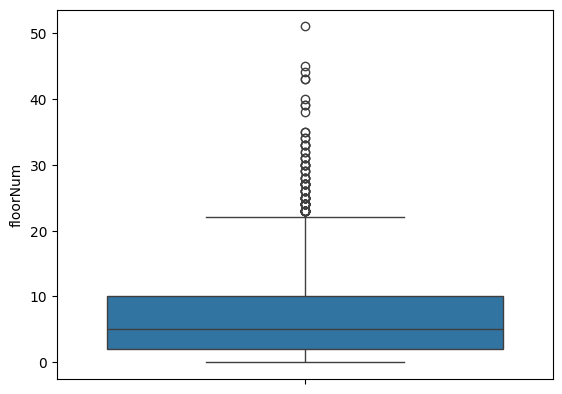

In [27]:
sns.boxplot(df['floorNum'])

In [28]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [29]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [30]:
train_df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,house,sector 4,0.58,2,2,1,2.0,Moderately Old,67.0,0,0,0,1,1,1,7,Low,Low Floor
1,flat,sector 77,1.25,3,4,3,3.0,Relatively New,1310.0,1,1,0,0,0,1,49,Low,Mid Floor
2,flat,sector 71,1.00,3,3,3+,3.0,Relatively New,1344.0,0,0,0,0,0,2,7,Low,Mid Floor
3,flat,sector 37c,1.20,3,3,3,7.0,Under Construction,1647.0,0,0,0,0,0,1,24,Low,Mid Floor
4,flat,sector 81,2.20,3,3,3+,5.0,Relatively New,1570.0,1,1,0,1,1,0,49,Low,Mid Floor


In [31]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [32]:
train_df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,house,sector 4,0.58,2,2,1,Moderately Old,67.0,0,0,0,1,1,1,Low,Low Floor
1,flat,sector 77,1.25,3,4,3,Relatively New,1310.0,1,1,0,0,0,1,Low,Mid Floor
2,flat,sector 71,1.00,3,3,3+,Relatively New,1344.0,0,0,0,0,0,2,Low,Mid Floor
3,flat,sector 37c,1.20,3,3,3,Under Construction,1647.0,0,0,0,0,0,1,Low,Mid Floor
4,flat,sector 81,2.20,3,3,3+,Relatively New,1570.0,1,1,0,1,1,0,Low,Mid Floor


In [33]:
from sklearn.preprocessing import OrdinalEncoder

#creating a copy of the original data for label encoding
data_label_encode = train_df.copy()

catagorical_col = train_df.select_dtypes(include=['object']).columns

for col in catagorical_col:
    oe = OrdinalEncoder()
    data_label_encode[col] = oe.fit_transform(data_label_encode[[col]])
    print(oe.categories_)

X_label = data_label_encode.drop('price',axis=1)
y_label = data_label_encode['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [34]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,47.0,2,2,1.0,0.0,67.0,0,0,0,1,1,1,1.0,1.0
1,0.0,87.0,3,4,3.0,3.0,1310.0,1,1,0,0,0,1,1.0,2.0
2,0.0,82.0,3,3,4.0,3.0,1344.0,0,0,0,0,0,2,1.0,2.0
3,0.0,43.0,3,3,3.0,4.0,1647.0,0,0,0,0,0,1,1.0,2.0
4,0.0,92.0,3,3,4.0,3.0,1570.0,1,1,0,1,1,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,0.0,105.0,3,3,3.0,3.0,1700.0,0,1,0,0,0,1,1.0,2.0
3480,0.0,0.0,3,3,2.0,4.0,1303.0,0,0,0,0,0,1,1.0,2.0
3481,0.0,4.0,2,2,2.0,3.0,1230.0,0,0,0,0,0,1,2.0,2.0
3482,0.0,15.0,3,4,2.0,3.0,2086.0,0,1,0,0,0,2,0.0,2.0


In [35]:
y_label

0        0.58
1        1.25
2        1.00
3        1.20
4        2.20
        ...  
3479     0.72
3480     1.30
3481     1.35
3482     2.65
3483    16.00
Name: price, Length: 3484, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

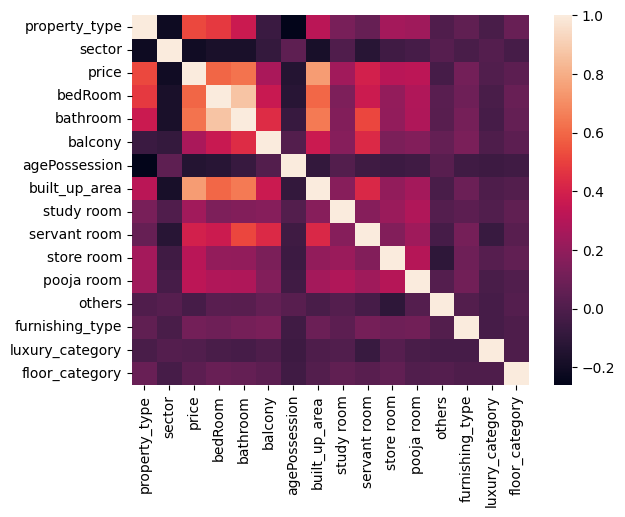

In [36]:
sns.heatmap(data_label_encode.corr(numeric_only=True))

In [38]:
fi_df1 = data_label_encode.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.204840
1,price,1.000000
2,bedRoom,0.594376
3,bathroom,0.628324
4,balcony,0.268229
5,agePossession,-0.141210
6,built_up_area,0.745767
7,study room,0.241771
8,servant room,0.395016
9,store room,0.312794


### Technique 2 - Random Forest Feature Importance

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators=100,random_state=42)
rf_label.fit(X_label,y_label)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
fi_df2 = pd.DataFrame(
    {
        'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
    }
).sort_values(by='rf_importance',ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.642982
0,property_type,0.110736
1,sector,0.106738
3,bathroom,0.026118
2,bedRoom,0.021440
8,servant room,0.019553
5,agePossession,0.015890
4,balcony,0.012238
12,furnishing_type,0.010034
9,store room,0.008745


### Technique 3 - Gradient Boosting Feature importances

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.671022
1,sector,0.109128
0,property_type,0.103430
2,bedRoom,0.035434
3,bathroom,0.026908
8,servant room,0.025429
9,store room,0.015327
5,agePossession,0.003993
12,furnishing_type,0.002905
7,study room,0.002362


### Technique 4 - Permutation Importance

In [42]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.633363
1,sector,0.148502
0,property_type,0.127261
4,balcony,0.006503
8,servant room,0.006222
9,store room,0.001666
11,others,0.001353
14,floor_category,0.001329
12,furnishing_type,-0.001807
3,bathroom,-0.002802


### Technique 5 - LASSO

In [43]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.418711
0,property_type,0.733957
3,bathroom,0.430252
9,store room,0.217493
7,study room,0.167240
8,servant room,0.147840
10,pooja room,0.092539
13,luxury_category,0.040475
12,furnishing_type,0.036309
14,floor_category,-0.001138


### Technique 6 - RFE

In [44]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.645536
0,property_type,0.106722
1,sector,0.106025
3,bathroom,0.024884
8,servant room,0.021888
2,bedRoom,0.020455
5,agePossession,0.015240
4,balcony,0.013283
12,furnishing_type,0.010602
9,store room,0.009727


### Technique 7 - Linear Regression Weights

In [46]:
from sklearn.linear_model import LinearRegression
# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.426025
0,property_type,0.747108
3,bathroom,0.510951
9,store room,0.221325
7,study room,0.175457
8,servant room,0.148921
10,pooja room,0.098563
13,luxury_category,0.051104
12,furnishing_type,0.044889
14,floor_category,-0.011284


In [47]:
!pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 6.1 MB/s  0:00:00

   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]




[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[ 0.45719993,  0.10614122, -0.0557047 , ..., -0.01445664,
        -0.00757429, -0.00511071],
       [-0.21558499, -0.14179472, -0.01202742, ..., -0.01552261,
        -0.00286243, -0.00857743],
       [-0.19707271, -0.17906156, -0.0124869 , ...,  0.00190973,
        -0.00370184, -0.01172554],
       ...,
       [-0.18096342,  0.03740487, -0.04931212, ..., -0.01286663,
         0.00489092, -0.00962367],
       [-0.37163272,  0.1674339 , -0.02528872, ...,  0.01379341,
         0.05487797, -0.03265574],
       [ 1.66626698,  1.82963874, -0.13704708, ...,  0.01957006,
        -0.02645861,  0.030601  ]], shape=(3484, 15))

In [49]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.238871
0,property_type,0.463341
1,sector,0.386151
3,bathroom,0.111033
8,servant room,0.092372
2,bedRoom,0.049590
4,balcony,0.038740
5,agePossession,0.028452
12,furnishing_type,0.026534
14,floor_category,0.023646


In [50]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [51]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.204840,0.106738,0.109128,0.148502,-0.053137,0.106025,-0.061441,0.386151
bedRoom,0.594376,0.021440,0.035434,-0.005833,-0.086014,0.020455,-0.176196,0.049590
bathroom,0.628324,0.026118,0.026908,-0.002802,0.430252,0.024884,0.510951,0.111033
balcony,0.268229,0.012238,0.001490,0.006503,-0.024742,0.013283,-0.043680,0.038740
agePossession,-0.141210,0.015890,0.003993,-0.006443,-0.007943,0.015240,-0.017129,0.028452
built_up_area,0.745767,0.642982,0.671022,0.633363,1.418711,0.645536,1.426025,1.238871
study room,0.241771,0.004991,0.002362,-0.010697,0.167240,0.004890,0.175457,0.012414
servant room,0.395016,0.019553,0.025429,0.006222,0.147840,0.021888,0.148921,0.092372
store room,0.312794,0.008745,0.015327,0.001666,0.217493,0.009727,0.221325,0.018923


In [52]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [53]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.725116
sector             0.148504
bathroom           0.027497
servant room       0.025572
bedRoom            0.020593
balcony            0.011525
store room         0.009838
agePossession      0.008951
furnishing_type    0.007382
floor_category     0.005709
luxury_category    0.004071
others             0.002145
pooja room         0.001949
study room         0.001147
dtype: float64

In [54]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,1.0,47.0,2,2,1.0,0.0,67.0,0,0,0,1,1,1,1.0,1.0
1,0.0,87.0,3,4,3.0,3.0,1310.0,1,1,0,0,0,1,1.0,2.0
2,0.0,82.0,3,3,4.0,3.0,1344.0,0,0,0,0,0,2,1.0,2.0
3,0.0,43.0,3,3,3.0,4.0,1647.0,0,0,0,0,0,1,1.0,2.0
4,0.0,92.0,3,3,4.0,3.0,1570.0,1,1,0,1,1,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,0.0,105.0,3,3,3.0,3.0,1700.0,0,1,0,0,0,1,1.0,2.0
3480,0.0,0.0,3,3,2.0,4.0,1303.0,0,0,0,0,0,1,1.0,2.0
3481,0.0,4.0,2,2,2.0,3.0,1230.0,0,0,0,0,0,1,2.0,2.0
3482,0.0,15.0,3,4,2.0,3.0,2086.0,0,1,0,0,0,2,0.0,2.0


In [55]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [57]:
scores.mean()

np.float64(0.8008331143052809)

In [58]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [59]:
scores.mean()

np.float64(0.8020999624314753)

In [60]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [61]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,1.0,47.0,2,2,1.0,0.0,67.0,0,0,1,1.0,1.0,0.58
1,0.0,87.0,3,4,3.0,3.0,1310.0,1,0,1,1.0,2.0,1.25
2,0.0,82.0,3,3,4.0,3.0,1344.0,0,0,2,1.0,2.0,1.00
3,0.0,43.0,3,3,3.0,4.0,1647.0,0,0,1,1.0,2.0,1.20
4,0.0,92.0,3,3,4.0,3.0,1570.0,1,0,0,1.0,2.0,2.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3479,0.0,105.0,3,3,3.0,3.0,1700.0,1,0,1,1.0,2.0,0.72
3480,0.0,0.0,3,3,2.0,4.0,1303.0,0,0,1,1.0,2.0,1.30
3481,0.0,4.0,2,2,2.0,3.0,1230.0,0,0,1,2.0,2.0,1.35
3482,0.0,15.0,3,4,2.0,3.0,2086.0,1,0,2,0.0,2.0,2.65


In [62]:
export_df.to_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_feature_selected.csv',index=False)